# Notebook 00: Baseline Induction

**Goal:** See induction heads in action. We'll generate repeated-token sequences,
run GPT-2 small on them, and plot how well the model predicts tokens in the
second (repeated) half vs. the first half.

If induction heads exist, the model should be *much* better at predicting tokens
in the second half — because it can look back and copy.

In [ ]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.insert(0, '..')

import torch
import numpy as np
import matplotlib.pyplot as plt
from transformer_lens import HookedTransformer

from src.data import make_induction_tokens
from src.metrics import induction_positions_and_targets, logit_diff

## Step 1: Load the model

TransformerLens wraps HuggingFace models and gives us hooks into every
internal activation. `gpt2-small` has 12 layers, 12 heads per layer.

In [ ]:
import os
os.environ['CUDA_VISIBLE_DEVICES'] = '2'

device = 'cuda' if torch.cuda.is_available() else 'cpu'
model = HookedTransformer.from_pretrained('gpt2-small', device=device)
print(f'Model: {model.cfg.model_name}, Layers: {model.cfg.n_layers}, Heads: {model.cfg.n_heads}')
print(f'Vocab size: {model.cfg.d_vocab}, Device: {device}, GPU: {torch.cuda.get_device_name(0)}')

## Step 2: Generate induction sequences

Each sequence: `[BOS, x0, x1, ..., x49, x0, x1, ..., x49]`

50 random tokens, repeated. Total length = 101.

In [4]:
N_CTX_HALF = 50
BATCH = 30

tokens = make_induction_tokens(
    batch=BATCH,
    n_ctx_half=N_CTX_HALF,
    bos_token_id=model.tokenizer.bos_token_id,
    seed=42,
)
print(f'Token shape: {tokens.shape}')  # [30, 101]
print(f'First sequence (first 10 tokens): {tokens[0, :10].tolist()}')
print(f'Verify repetition: first half == second half? {torch.equal(tokens[0, 1:N_CTX_HALF+1], tokens[0, N_CTX_HALF+1:])}')

Token shape: torch.Size([30, 101])
First sequence (first 10 tokens): [50256, 5542, 8067, 26876, 8414, 23026, 13335, 27620, 21924, 36950]
Verify repetition: first half == second half? True


## Step 3: Run the model and get logits

The model returns logits of shape `[batch, seq_len, vocab_size]`.
At each position, the logit vector tells us how likely the model
thinks each vocab token is as the *next* token.

In [5]:
with torch.no_grad():
    logits = model(tokens.to(device))  # [batch, seq_len, vocab_size]

print(f'Logits shape: {logits.shape}')

Logits shape: torch.Size([30, 101, 50257])


## Step 4: Compute per-position loss

Instead of just our metric, let's look at the **loss at every position**.
This gives us the full picture:
- First half: model has never seen these random tokens, so loss should be HIGH
- Second half: if induction works, the model recognizes the repetition and loss DROPS

We use cross-entropy loss: lower = model is more confident about the correct next token.

In [6]:
# Compute per-position cross-entropy loss
# At position i, the target is the token at position i+1
log_probs = torch.log_softmax(logits, dim=-1)  # [batch, seq_len, vocab]

# Shift: at position i, we predict token at i+1
# So we compare logits[:, :-1, :] against tokens[:, 1:]
target_tokens = tokens[:, 1:].to(device)  # [batch, seq_len - 1]
per_pos_log_prob = log_probs[:, :-1, :].gather(2, target_tokens.unsqueeze(2)).squeeze(2)  # [batch, seq_len-1]
per_pos_loss = -per_pos_log_prob  # cross-entropy = negative log prob

# Average across batch
avg_loss_by_pos = per_pos_loss.mean(dim=0).cpu()  # [seq_len - 1]

print(f'Per-position loss shape: {avg_loss_by_pos.shape}')
print(f'Mean loss, first half (pos 1-{N_CTX_HALF}): {avg_loss_by_pos[:N_CTX_HALF].mean():.3f}')
print(f'Mean loss, second half (pos {N_CTX_HALF+1}-{2*N_CTX_HALF}): {avg_loss_by_pos[N_CTX_HALF:].mean():.3f}')

Per-position loss shape: torch.Size([100])
Mean loss, first half (pos 1-50): 13.120
Mean loss, second half (pos 51-100): 0.471


## Step 5: Plot it!

This is Figure 1 of our project. You should see:
- High loss in the first half (random tokens, no way to predict)
- Sharp drop in loss at the start of the second half (induction kicks in)

The DROP is the induction signal. That's what we'll trace to specific heads.

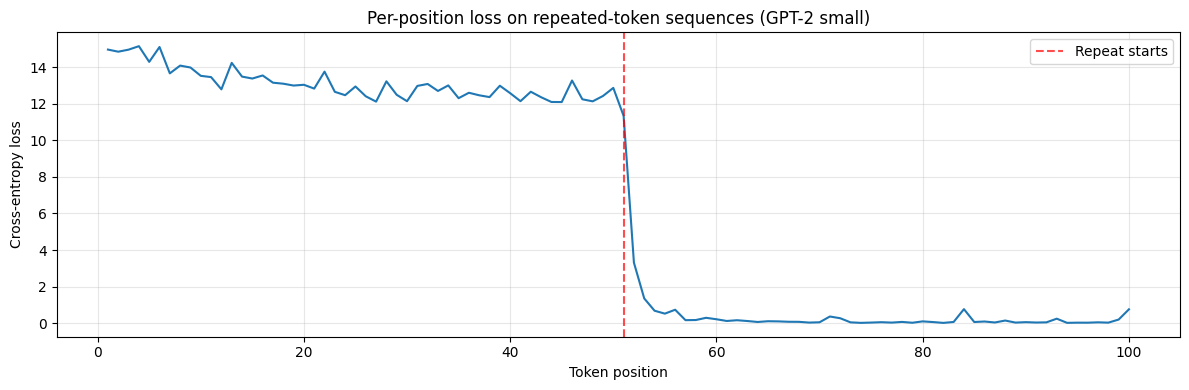


If you see a sharp loss drop after the red line, induction heads are working!


In [7]:
fig, ax = plt.subplots(figsize=(12, 4))

positions = np.arange(1, len(avg_loss_by_pos) + 1)
ax.plot(positions, avg_loss_by_pos.numpy(), linewidth=1.5)

# Mark the boundary between first and second half
ax.axvline(x=N_CTX_HALF + 1, color='red', linestyle='--', alpha=0.7, label='Repeat starts')

ax.set_xlabel('Token position')
ax.set_ylabel('Cross-entropy loss')
ax.set_title('Per-position loss on repeated-token sequences (GPT-2 small)')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../results/figures/fig1_baseline_induction.png', dpi=150)
plt.show()

print('\nIf you see a sharp loss drop after the red line, induction heads are working!')

## Step 6: Sanity check — logit difference metric

This is the metric we'll use throughout the project for patching and ablation.
It should be positive and large if induction is working.

In [8]:
eval_positions, eval_targets = induction_positions_and_targets(tokens, N_CTX_HALF)
ld = logit_diff(logits, eval_positions.to(device), eval_targets.to(device))
print(f'Logit difference (clean, no corruption): {ld.item():.3f}')
print(f'(Positive = model prefers the correct induction token over the average alternative)')

Logit difference (clean, no corruption): 21.541
(Positive = model prefers the correct induction token over the average alternative)


## What we learned

1. GPT-2 small has induction behavior: loss drops sharply in the repeated half
2. Our logit_diff metric captures this quantitatively
3. **Next question:** Which components (layers, heads) are responsible?
   → That's Notebook 01 (activation patching)